<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.3 Tensão Tangencial Máxima. Círculo de Mohr.

## Problema 2 <a name="PI32"></a>

Considere uma barra sujeita ao seguinte estado de tensão:

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
4 & 0 & \sqrt{5} \\
0 & -15 & 0 \\
\sqrt{5} & 0 & 4
\end{bmatrix}\times 10^7\textrm{Pa}
\end{equation*}

[(a)](#A) Desenhe o circulo de Mohr e calcule as tensões principais, e as tensões de corte máximas.

[(b)](#B) Em que plano ocorre a tensão de corte máxima?

## Resolução

#### a) Desenhe o circulo de Mohr e calcule as tensões principais, e as tensões de corte máximas.<a name="A"></a>

([enunciatum](#PI32))

Leis de transformação da matriz do tensor das tensões:

/tmp/ipykernel_36428/312721663.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn')
/tmp/ipykernel_36428/312721663.py:24: RuntimeWarning: divide by zero encountered in double_scalars
  return np.arctan(2*txy/(sxx-syy))/2



Matriz das tensões tt0 = 
 [[  40.       0.      22.361]
 [   0.    -150.       0.   ]
 [  22.361    0.      40.   ]]  MPa

PLANO x-z:

angPrincipal 1 (deg) = 45.00
tens xx plano principal [1] (MPa) = 62.36
tens yy plano principal [1] (MPa) = 17.64
tens xy plano principal [1] (MPa) = 0.00

angPrincipal 2 (deg) = 135.00
tens xx plano principal [2] (MPa) = 17.64
tens yy plano principal [2] (MPa) = 62.36
tens xy plano principal [2] (MPa) = 0.00


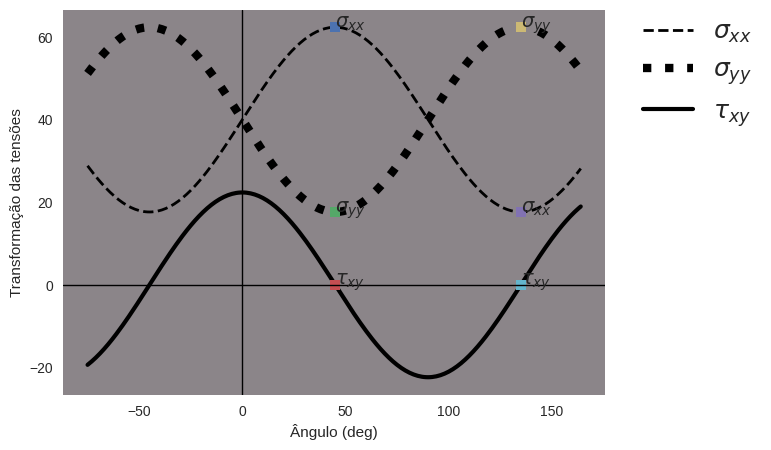

In [17]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.style.use('seaborn')

np.set_printoptions(precision=3)

def sij(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

tt0 = sij(4,0,np.sqrt(5),-15,0,4)*10 # unidades: MPa
print('\nMatriz das tensões tt0 = \n',tt0,' MPa')

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

print('\nPLANO x-z:\n')
sxx = tt0[0,0] # neste caso: x = y; y = z
txy = tt0[0,2]
syy = tt0[2,2]

angt = np.arange(-75,165,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal 1 (deg) =','{:.2f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens xx plano principal [1] (MPa) =','{:.2f}'.format(tsxx1))
print('tens yy plano principal [1] (MPa) =','{:.2f}'.format(tsyy1))
print('tens xy plano principal [1] (MPa) =','{:.2f}'.format(ttxy1))

aprinc2 = aprinc + 90
print('\nangPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.2f}'.format(tsxx2))
print('tens yy plano principal [2] (MPa) =','{:.2f}'.format(tsyy2))
print('tens xy plano principal [2] (MPa) =','{:.2f}'.format(np.abs(ttxy2)))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

font = {'size' : 14}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='#8B8589'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=2)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=6)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
ax.plot(aprinc, tsxx1, 's'), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 's'), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's'), ax.text(aprinc, ttxy1,r'$\tau_{xy}$')
ax.plot(aprinc2, tsxx2, 's'), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 's'), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's'), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

Analise algébrica das tensões principais

1º Invariante, I1: -70.0
2º Invariante, I2 : -10900.0
3º Invariante, I3 : -165000.0

 Raizes polinómio caraterístico: resolucao Numerica - Numpy : ............................
Numpy : roots =  [-150.      62.361   17.639]

 Tensão principal (valor próprio) sI  = 62.36
Tensão principal (valor próprio) sII  = 17.64
Tensão principal (valor próprio) sIII = -150.00


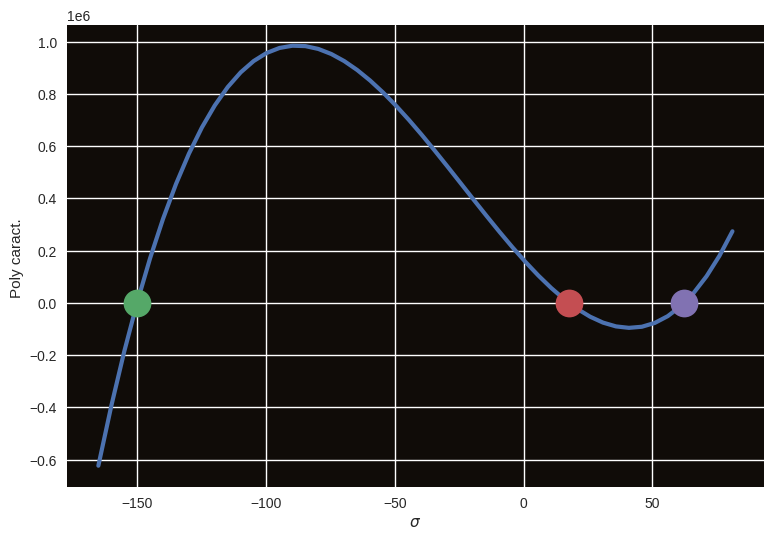

In [18]:
print('=========================================')
print('Analise algébrica das tensões principais')
print('=========================================\n')

I1 = np.trace(tt0)
print('1º Invariante, I1:', '{:.1f}'.format(I1))
I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))
I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Raizes polinómio caraterístico: resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('Numpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('\n Tensão principal (valor próprio) sI  =','{:.2f}'.format(sI))
print('Tensão principal (valor próprio) sII  =','{:.2f}'.format(sII))
print('Tensão principal (valor próprio) sIII =','{:.2f}'.format(sIII))

srange = np.linspace(np.min(valpropriosN)*1.1,np.max(valpropriosN)*1.3)
def polycaract(s):
    return s**3 - I1*s**2 + I2*s - I3
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor']='#100C08'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valpropriosN:
    plt.plot(i,polycaract(i),'o',markersize=20)
plt.ylabel('Poly caract. ')
plt.xlabel('$\sigma$')
plt.grid('on')
plt.show()

In [19]:
print('=========================================')
print('Analise algébrica das direções principais')
print('=========================================\n')

import sympy as sy
from sympy.solvers import solve
from sympy import symbols

nx,ny,nz = symbols('nx ny nz')

def eq1(nx,ny,nz,vp): return (tt0[0,0] - vp)*nx + tt0[0,1]*ny + tt0[0,2]*nz
def eq2(nx,ny,nz,vp): return tt0[1,0]*nx + (tt0[1,1] - vp)*ny + tt0[1,2]*nz
def eq3(nx,ny,nz,vp): return tt0[2,0]*nx + tt0[2,1]*ny + (tt0[2,2] - vp)*nz
def eq4(nx,ny,nz): return nx**2 + ny**2 + nz**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('--------------------------------')
print('Vetor próprio associado a sI = ','{:.2f}'.format(sI),' MPa ')
print('--------------------------------')
print('\n(i) sistema de equações:')
E1_sI = eq1(nx,ny,nz,sI); print(E1_sI,' = 0')
E2_sI = eq2(nx,ny,nz,sI); print(E2_sI,' = 0')
E3_sI = eq3(nx,ny,nz,sI); print(E3_sI,' = 0')
E4_sI = eq4(nx,ny,nz); print(E4_sI,' = 0')
VetProp1 = solve([E1_sI,E2_sI,E4_sI], [nx,ny,nz], dict=True)
l1 = float(VetProp1[1][nx])
m1 = float(VetProp1[1][ny])
n1 = float(VetProp1[1][nz])
versorI = versor(l1,m1,n1)
print('\n(ii) nI = ','{:.3f}'.format(l1),'i +','{:.3f}'.format(m1),'j +','{:.3f}'.format(n1),'k')

Analise algébrica das direções principais

--------------------------------
Vetor próprio associado a sI =  62.36  MPa 
--------------------------------

(i) sistema de equações:
-22.360679774998*nx + 22.3606797749979*nz  = 0
-212.360679774998*ny  = 0
22.3606797749979*nx - 22.360679774998*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nI =  0.707 i + 0.000 j + 0.707 k


In [20]:
# 2 valor proprio -------------------
print('--------------------------------')
print('Vetor próprio associado a sII= ','{:.2f}'.format(sII),' MPa')
print('--------------------------------')
print('\n(i) sistema de equações:')
E1_sII = eq1(nx,ny,nz,sII); print(E1_sII,' = 0')
E2_sII = eq2(nx,ny,nz,sII); print(E2_sII,' = 0')
E3_sII = eq3(nx,ny,nz,sII); print(E3_sII,' = 0')
E4_sII = eq4(nx,ny,nz); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E2_sII,E4_sII], [nx,ny,nz], dict=True)
l2 = float(VetProp2[0][nx])
m2 = float(VetProp2[0][ny])
n2 = float(VetProp2[0][nz])
versorII = versor(l2,m2,n2)
print('\n(ii) nII = (','{:.3f}'.format(l2),') i + (','{:.3f}'.format(m2),') j + (','{:.3f}'.format(n2),') k')

--------------------------------
Vetor próprio associado a sII=  17.64  MPa
--------------------------------

(i) sistema de equações:
22.3606797749979*nx + 22.3606797749979*nz  = 0
-167.639320225002*ny  = 0
22.3606797749979*nx + 22.3606797749979*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nII = ( -0.707 ) i + ( 0.000 ) j + ( 0.707 ) k


In [21]:
# 3 valor proprio -------------------
print('--------------------------------')
print('Vetor próprio associado a sIII= ','{:.2f}'.format(sIII),' MPa ')
print('--------------------------------')
print('\n(i) sistema de equações:')
E1_sIII = eq1(nx,ny,nz,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(nx,ny,nz,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(nx,ny,nz,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(nx,ny,nz); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E3_sIII,E4_sIII], [nx,ny,nz], dict=True)
l3 = float(VetProp3[1][nx])
m3 = float(VetProp3[1][ny])
n3 = float(VetProp3[1][nz])
versorIII = versor(l3,m3,n3)
print('\n(ii) nIII = (','{:.3f}'.format(l3),') i + (','{:.3f}'.format(m3),') j + (','{:.3f}'.format(n3),') k')

--------------------------------
Vetor próprio associado a sIII=  -150.00  MPa 
--------------------------------

(i) sistema de equações:
190.0*nx + 22.3606797749979*nz  = 0
5.6843418860808e-14*ny  = 0
22.3606797749979*nx + 190.0*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nIII = ( 0.000 ) i + ( 1.000 ) j + ( 0.000 ) k


In [22]:
print('\n Interpretação das orientações dos referenciaisis:\n ')

print('\n Verificações para os versores principais: ')
print('dot(vp1,vp1) = ','{:.1f}'.format(np.dot(versorI,versorI)))
print('dot(vp2,vp2) = ', '{:.1f}'.format(np.dot(versorII,versorII)))
print('dot(vp3,vp3) = ', '{:.1f}'.format(np.dot(versorIII,versorIII)))
print('dot(vp1,vp2) = ', '{:.1f}'.format(np.abs(np.dot(versorI,versorII))))
print('dot(vp2,vp3) = ', np.dot(versorII,versorIII))
print('dot(vp1,vp3) = ', np.dot(versorI,versorIII))


 Interpretação das orientações dos referenciaisis:
 

 Verificações para os versores principais: 
dot(vp1,vp1) =  1.0
dot(vp2,vp2) =  1.0
dot(vp3,vp3) =  1.0
dot(vp1,vp2) =  0.0
dot(vp2,vp3) =  0.0
dot(vp1,vp3) =  0.0


Para verificação, o tensor das tensões no referencial princiapl obtém-se pela seguiinte lei de transformação de um
tensor de segunda ordem simétrico:

\begin{equation*}
\begin{aligned}
\underline{\underline{\sigma}}_P&=\underline{\underline{T}}_{0P}\,\underline{\underline{\sigma}}_0~
\underline{\underline{T}}_{0P}^T
\end{aligned}
\end{equation*}

In [23]:
np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

xP = versorI
yP = versorIII
zP = versorII

np.set_printoptions(precision=3,suppress=True)

MatrTrans = np.array([xP,yP,zP])
print('MatrTrans = \n',MatrTrans)
sprinc = np.dot(MatrTrans,np.dot( tt0 ,np.transpose(MatrTrans) ))
print('Matriz das tensões no refencial principal = \n',sprinc)


 Matriz de transformação de S0 para SI (ref. principal): 
MatrTrans = 
 [[ 0.707  0.     0.707]
 [ 0.     1.     0.   ]
 [-0.707  0.     0.707]]
Matriz das tensões no refencial principal = 
 [[  62.361    0.       0.   ]
 [   0.    -150.       0.   ]
 [   0.       0.      17.639]]


de onde resulta,

\begin{equation*}
\underline{\underline{\sigma}}_P =
\begin{bmatrix}
\sigma_\mathrm{I} & 0 & 0 \\
0 & \sigma_\mathrm{III} & 0 \\
0 & 0 & \sigma_\mathrm{II} \\
\end{bmatrix} =
\begin{bmatrix}
62.361 & 0 & 0 \\
0 &  -150.  & 0 \\
0 & 0 & 17.639 \\
\end{bmatrix}~\textrm{MPa}
\end{equation*}

In [24]:
print('\n Àngulo entre xP e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

print('Versor principal xP: \n')
xPx = np.rad2deg(np.arccos(float(xP[0])))
print('xP.x = ','{:.2f}'.format(xPx),'º')
xPy = np.rad2deg(np.arccos(float(xP[1])))
print('xP.y = ','{:.2f}'.format(xPy),'º')
xPz = np.rad2deg(np.arccos(float(xP[2])))
print('xP.z = ','{:.2f}'.format(xPz),'º')

print('\nVersor principal yP: \n')
yPx = np.rad2deg(np.arccos(float(yP[0])))
print('yP.x = ','{:.2f}'.format(yPx),'º')
yPy = np.rad2deg(np.arccos(float(yP[1])))
print('yP.y = ','{:.2f}'.format(yPy),'º')
yPz = np.rad2deg(np.arccos(float(yP[2])))
print('yP.z = ','{:.2f}'.format(yPz),'º')

print('\nVersos principal zP: \n')
zPx = np.rad2deg(np.arccos(float(zP[0])))
print('zP.x = ','{:.2f}'.format(zPx),'º')
zPy = np.rad2deg(np.arccos(float(zP[1])))
print('zP.y = ','{:.2f}'.format(zPy),'º')
zPz = np.rad2deg(np.arccos(float(zP[2])))
print('zP.z = ','{:.2f}'.format(zPz),'º')

mT = np.concatenate((xP, yP, zP))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))

print('\nverificacao: ni.ni = 1 ')
eI2 = np.sqrt(np.dot(mT[0,:],mT[0,:]))
print('T[0,:] : eI2 = ','{:.2f}'.format(eI2))
eII2 = np.sqrt(np.dot(mT[1,:],mT[1,:]))
print('T[1,:] : eII2 = ','{:.2f}'.format(eII2))
eIII2 = np.sqrt(np.dot(mT[2,:],mT[2,:]))
print('T[2,:] : eII2 = ','{:.2f}'.format(eIII2))


 Àngulo entre xP e x: 

 theta_P =  45.00  Deg
Versor principal xP: 

xP.x =  45.00 º
xP.y =  90.00 º
xP.z =  45.00 º

Versor principal yP: 

yP.x =  90.00 º
yP.y =  0.00 º
yP.z =  90.00 º

Versos principal zP: 

zP.x =  135.00 º
zP.y =  90.00 º
zP.z =  45.00 º

 [T] = 
 [[ 0.707  0.     0.707]
 [ 0.     1.     0.   ]
 [-0.707  0.     0.707]]

[T][T]^T = I :
 [[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

 det(T) =  1.00

verificacao: ni.ni = 1 
T[0,:] : eI2 =  1.00
T[1,:] : eII2 =  1.00
T[2,:] : eII2 =  1.00


In [25]:
np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre eI e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

mT = np.concatenate((versorI, versorIII,versorII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ',np.linalg.det(mT))


 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 

 theta_P =  45.00  Deg

 [T] = 
 [[ 0.707  0.     0.707]
 [ 0.     1.     0.   ]
 [-0.707  0.     0.707]]

[T][T]^T = I :
 [[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

 det(T) =  1.0



PLANO x-z:
  Tensão normal mínima:  17.639
  Tensão normal máxima:  62.361
  Tensão normal média :  40.0
Tensão de corte mínima:  -22.361
Tensão de corte máxima:  22.361
Ponto A ( 40.0 , -22.4 )
Ponto B ( 40.0 , 22.4 )


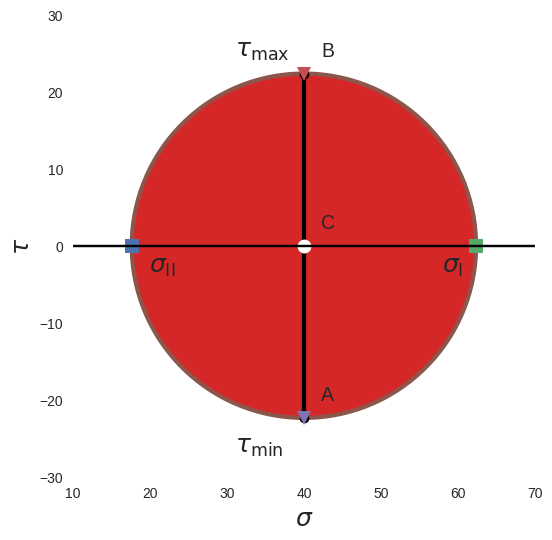

In [26]:
def mohr(E,limits):
    """Plot Mohr circle for a 2D tensor"""
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    Emin = center[0] - radius
    Emax = center[0] + radius

    print("  Tensão normal mínima: ", np.round(Emin,3))
    print("  Tensão normal máxima: ", np.round(Emax, 3))
    print("  Tensão normal média : ", np.round(center[0], 3))
    print("Tensão de corte mínima: ", np.round(-radius, 3))
    print("Tensão de corte máxima: ", np.round(radius, 3))

    print('Ponto A (','{:.1f}'.format(E11),',','{:.1f}'.format(-E12),')')
    print('Ponto B (','{:.1f}'.format(E22),',','{:.1f}'.format(E12),')')

    plt.rcParams['axes.facecolor']='white'
    fig, ax = plt.subplots(figsize=(9, 6))
    circ = plt.Circle((center[0],0), radius, facecolor='#d62728', lw=3,
    edgecolor='#8c564b')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Emin - .3*radius, Emax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([E11, E22], [-E12, E12], 'ko', linewidth=3)
    plt.plot([E11, E22], [-E12, E12], 'k', linewidth=3)
    plt.plot(Emin, 0, 's', markersize=10)
    plt.plot(Emax, 0, 's', markersize=10)
    plt.plot(center[0], radius, 'v', markersize=10)
    plt.plot(center[0], -radius, 'v', markersize=10)
    plt.plot(center[0], center[1], 'o', mfc='w', markersize=10)
    plt.text(center[0]+desv, desv, 'C')
    plt.text(E11 + desv, -E12 + desv , 'A')
    plt.text(E22 + desv, E12 + desv, 'B')
    plt.text(Emin + .1*radius, -0.15*radius, \
             r'$\sigma_\mathrm{II}$', fontsize = 18)
    plt.text(Emax - .2*radius, -0.15*radius, \
             r'$\sigma_\mathrm{I}$', fontsize = 18)
    plt.text(center[0]-4*desv, 1.1*radius, \
             r'$\tau_\mathrm{max}$', fontsize = 18)
    plt.text(center[0]-4*desv, -1.2*radius, \
             r'$\tau_\mathrm{min}$', fontsize = 18)
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[10,70],[-30,30]])
print('\n================================')
print('PLANO x-z:')
print('================================')
exx = tt0[0,0]
eyy = tt0[2,2]
exy = tt0[0,2]
E1 = np.array([[exx, exy],[exy, eyy]])
mohr(E1, axislim)

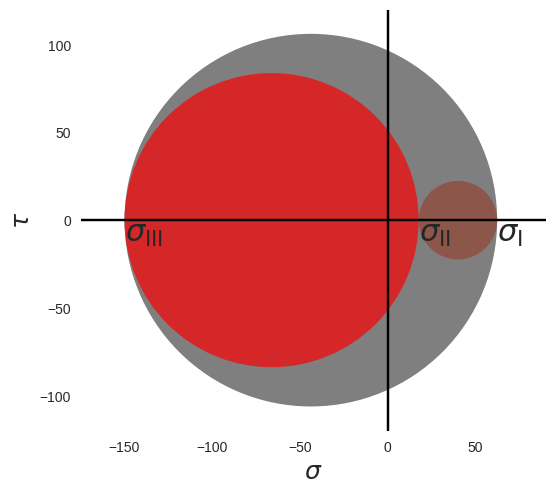

In [27]:
def circleradius(S):
    S11 = S[0,0]
    S12 = S[0,1]
    S22 = S[1,1]

    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)

    return center, radius

limits = np.array([[-175,90],[-120,120]])

sigI = sI
sigII = sII
sigIII = sIII

s11 = sigI; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center1, radius1  = circleradius(S)

s11 = sigI; s22 = sigII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center2, radius2  = circleradius(S)

s11 = sigII; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center3, radius3  = circleradius(S)

plt.rcParams['axes.facecolor']='white'
fig, ax = plt.subplots(figsize=(6, 6))
circ1 = plt.Circle((center1[0],0), radius1, facecolor='#7f7f7f')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='#8c564b')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='#d62728')

plt.axis('image'); ax = plt.gca()
plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ3)

plt.xlabel(r"$\sigma$", size=18)
plt.ylabel(r"$\tau$", size=18)

plt.text(1.*sigI, -12, r'$\sigma_\mathrm{I}$', fontsize=22)
plt.text(1.*sigII, -12, r'$\sigma_\mathrm{II}$', fontsize=22)
plt.text(1.*sigIII, -12, r'$\sigma_\mathrm{III}$', fontsize=22)

plt.xlim(limits[0,0],limits[0,1])
plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

#### b) Em que plano ocorre a tensão de corte máxima?<a name="B"></a>

([enunciatum](#PI32))

A análise do circulo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões num determinado plano de análise. Considere-se esse plano $Oyz$, vem então:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{max/min} &= \sigma_\mathrm{médio} \pm R \\
&= \frac{\sigma_{xx} + \sigma_{zz}}{2} \pm  \sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2 +
\tau_{xz}^2 }
\end{aligned}
\end{equation*}

In [28]:
sxx = tt0[0,0]
szz = tt0[2,2]
sxz = tt0[0,2]

Smedio = (sxx+szz)/2
Raio = (((sxx-szz)/2)**2 + sxz**2)**(1/2)

sigma_max = Smedio + Raio
print('sigma_max = ','{:.2f}'.format(sigma_max),' MPa')
sigma_min = Smedio - Raio
print('sigma_min = ','{:.2f}'.format(sigma_min),' MPa')

sigma_max =  62.36  MPa
sigma_min =  17.64  MPa


Considere-se o plano $Oxz$ (o eixo dos $yy$ é direção principal de tensão sendo $\sigma_{yy}$ uma tensão principal de
tensão). Tensão de corte máxima e mínima podem ser obtidas algebricamente por:

\begin{equation*}
\begin{aligned}
\tau_\mathrm{max/min} &= R =
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2 +
\tau_{xz}^2 }
\end{aligned}
\end{equation*}

In [29]:
tau_max = Raio
print('tau_max = ','{:.2f}'.format(tau_max),' MPa')
tau_min = -Raio
print('tau_min = ','{:.2f}'.format(tau_min),' MPa')

tau_max =  22.36  MPa
tau_min =  -22.36  MPa


In [39]:
def raiodef(s11,s22,s12):
    return np.sqrt( ((s11-s22)/2)**2 + s12**2 )

# plano x-z
rxz_ = raiodef(tt0[0,0],tt0[2,2],tt0[0,2])
print(f'plano x-z : R = {rxz_:.3f} MPa')

# plano x-y
rxy_ = raiodef(tt0[1,1],tt0[0,0],tt0[0,1])
print(f'plano x-y : R = {rxy_:.3f} MPa')

# plano y-z
ryz_ = raiodef(tt0[1,1],tt0[2,2],tt0[1,2])
print(f'plano y-z : R = {ryz_:.3f} MPa')

plano x-z : R = 22.361 MPa
plano x-y : R = 95.000 MPa
plano y-z : R = 95.000 MPa


O ângulo que o eixo perpendicular ao plano onde atua $\tau_\mathrm{\max}$ faz com os eixos no plano $x-z$:

\begin{equation*}
\begin{aligned}
2\theta_{S} &= \arctan \left(-\frac{\sigma_{xx}-\sigma_{zz}}{2\tau_{xz}}\right) \\[1ex]
\end{aligned}
\end{equation*}


In [31]:
def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

aS1 = angS(sxx,szz,sxz)
aS2 = aS1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angSI:  ','{:.3f}'.format(np.rad2deg(aS1)),' deg | ','{:.3f}'.format(aS1),' radians')
print('angSII: ','{:.3f}'.format(np.rad2deg(aS2)),' deg | ','{:.3f}'.format(aS2),' radians')

aSI = aS1/2
aSII = aS2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aSI)),' deg | ','{:.3f}'.format(aSI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aSII)),' deg | ','{:.3f}'.format(aSII),' radians')

angulos das direções principais

No espaço das tensões:
angSI:   -0.000  deg |  -0.000  radians
angSII:  180.000  deg |  3.142  radians

No espaço fisico:
angPI:   -0.000  deg |  -0.000  radians
angPII:  90.000  deg |  1.571  radians


A tensão de corte máxima por definição é dada por:

\begin{equation*}
\tau_\mathrm{max} = \frac{\sigma_\mathrm{I} - \sigma_\mathrm{III}}{2}
\end{equation*}

In [32]:
tmax = (sI - sIII)/2
print('Tensão de corte máxima = ', '{:.3f}'.format(tmax),' MPa')

Tensão de corte máxima =  106.180  MPa



PLANO x-y:



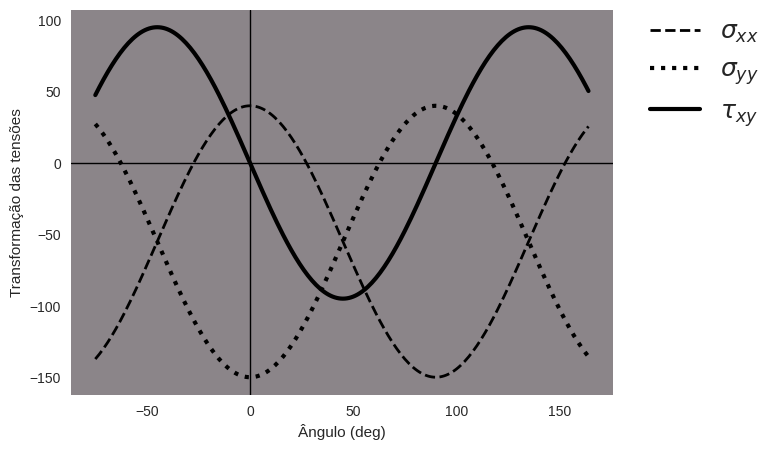

In [33]:
print('\nPLANO x-y:\n')
sxx = tt0[0,0] # neste caso: x = y; y = z
txy = tt0[0,1]
syy = tt0[1,1]

angt = np.arange(-75,165,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

plt.rcParams['axes.facecolor']='#8B8589'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=2)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


PLANO y-z:



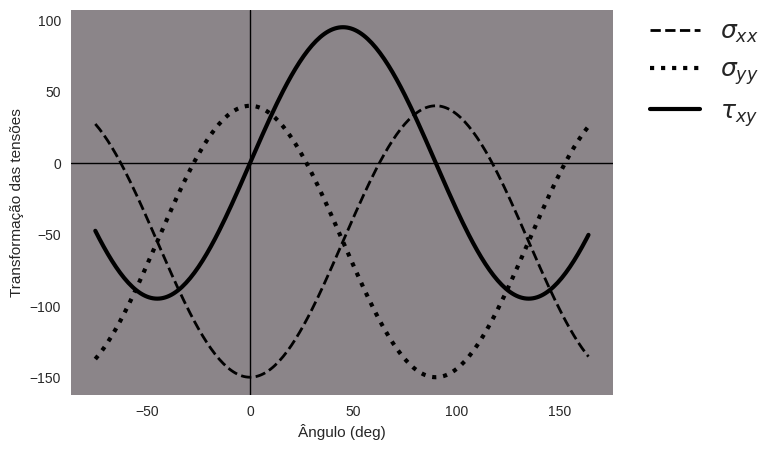

In [34]:
print('\nPLANO y-z:\n')
sxx = tt0[1,1] # neste caso: x = y; y = z
txy = tt0[1,2]
syy = tt0[2,2]

angt = np.arange(-75,165,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

plt.rcParams['axes.facecolor']='#8B8589'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=2)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


PLANO Principal I-III:



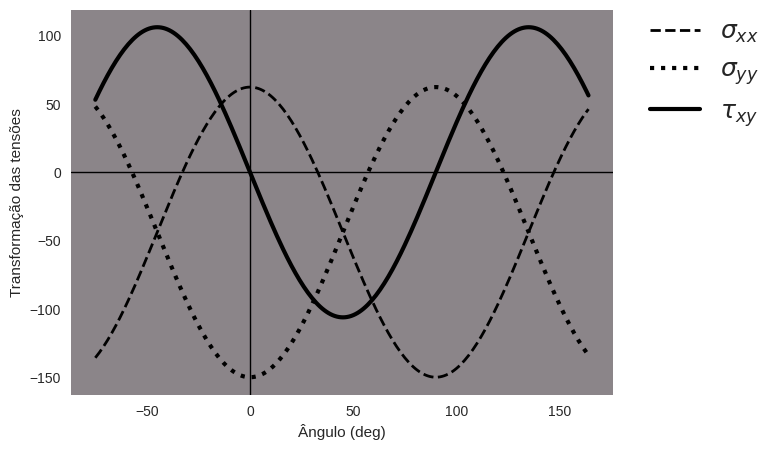

In [35]:
print('\nPLANO Principal I-III:\n')
sxx = sprinc[0,0] # neste caso: x = y; y = z
txy = sprinc[0,1]
syy = sprinc[1,1]

angt = np.arange(-75,165,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

plt.rcParams['axes.facecolor']='#8B8589'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=2)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


PLANO Principal II-III:



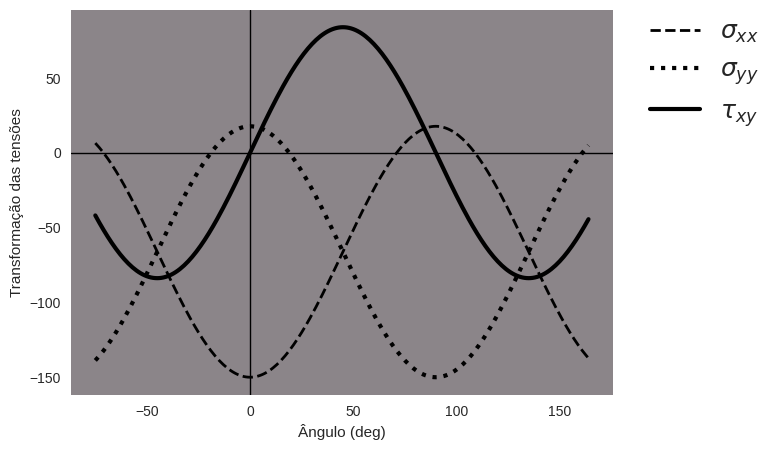

In [36]:
print('\nPLANO Principal II-III:\n')
sxx = sprinc[1,1] # neste caso: x = y; y = z
txy = sprinc[1,2]
syy = sprinc[2,2]

angt = np.arange(-75,165,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

plt.rcParams['axes.facecolor']='#8B8589'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=2)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>